# **Flight Delay Dataset EDA**
#### *Numbers, correlations, and cutting the fat before modeling*

## **Setup**

In [18]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

pl.Config.set_tbl_rows(30)

polars.config.Config

## **1. Load + Sanity Check**

In [19]:
df = pl.read_csv("../data/flightsData1m.csv")
print(df.shape)
df.head()

(1000000, 61)


FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings
str,str,str,str,bool,bool,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,str,str,i64,str,i64,str,i64,str,str,i64,i64,i64,i64,str,str,i64,str,i64,i64,i64,i64,str,str,i64,str,i64,f64,f64,str,f64,f64,f64,f64,i64,f64,f64,f64,str,i64,i64
"""2022-01-30""","""Alaska Airlines Inc.""","""BUR""","""SEA""",false,false,700,648.0,0.0,-12.0,927.0,0.0,133.0,165.0,159.0,937.0,2022,1,1,30,7,"""AS""","""AS""",19930,"""AS""",961,"""AS""",19930,"""AS""","""N238AK""",961,10800,1080003,32575,"""Burbank, CA""","""CA""",6,"""California""",91,14747,1474703,30559,"""Seattle, WA""","""WA""",53,"""Washington""",93,0.0,-1.0,"""0700-0759""",15.0,703.0,916.0,11.0,945,-18.0,0.0,-2.0,"""0900-0959""",4,0
"""2022-07-10""","""Delta Air Lines Inc.""","""LAX""","""DFW""",false,false,845,920.0,35.0,35.0,1422.0,22.0,159.0,195.0,182.0,1235.0,2022,3,7,10,7,"""DL""","""DL""",19790,"""DL""",1041,"""DL""",19790,"""DL""","""N367NW""",1041,12892,1289208,32575,"""Los Angeles, CA""","""CA""",6,"""California""",91,11298,1129806,30194,"""Dallas/Fort Worth, TX""","""TX""",48,"""Texas""",74,1.0,2.0,"""0800-0859""",13.0,933.0,1412.0,10.0,1400,22.0,1.0,1.0,"""1400-1459""",5,0
"""2022-03-25""","""Southwest Airlines Co.""","""DAL""","""DEN""",false,false,915,930.0,15.0,15.0,1027.0,7.0,104.0,125.0,117.0,651.0,2022,1,3,25,5,"""WN""","""WN""",19393,"""WN""",825,"""WN""",19393,"""WN""","""N7888A""",825,11259,1125904,30194,"""Dallas, TX""","""TX""",48,"""Texas""",74,11292,1129202,30325,"""Denver, CO""","""CO""",8,"""Colorado""",82,1.0,1.0,"""0900-0959""",9.0,939.0,1023.0,4.0,1020,7.0,0.0,0.0,"""1000-1059""",3,0
"""2022-06-04""","""American Airlines Inc.""","""SJU""","""PHL""",false,false,1320,1318.0,0.0,-2.0,1707.0,0.0,203.0,243.0,229.0,1576.0,2022,2,6,4,6,"""AA""","""AA""",19805,"""AA""",1496,"""AA""",19805,"""AA""","""N928AM""",1496,14843,1484306,34819,"""San Juan, PR""","""PR""",72,"""Puerto Rico""",3,14100,1410005,34100,"""Philadelphia, PA""","""PA""",42,"""Pennsylvania""",23,0.0,-1.0,"""1300-1359""",20.0,1338.0,1701.0,6.0,1723,-16.0,0.0,-2.0,"""1700-1759""",7,0
"""2022-01-21""","""American Airlines Inc.""","""PHX""","""LAS""",false,false,1552,1545.0,0.0,-7.0,1557.0,0.0,49.0,71.0,72.0,255.0,2022,1,1,21,5,"""AA""","""AA""",19805,"""AA""",1541,"""AA""",19805,"""AA""","""N405AN""",1541,14107,1410702,30466,"""Phoenix, AZ""","""AZ""",4,"""Arizona""",81,12889,1288903,32211,"""Las Vegas, NV""","""NV""",32,"""Nevada""",85,0.0,-1.0,"""1500-1559""",14.0,1559.0,1548.0,9.0,1603,-6.0,0.0,-1.0,"""1600-1659""",2,0


In [20]:
df.schema

Schema([('FlightDate', String),
        ('Airline', String),
        ('Origin', String),
        ('Dest', String),
        ('Cancelled', Boolean),
        ('Diverted', Boolean),
        ('CRSDepTime', Int64),
        ('DepTime', Float64),
        ('DepDelayMinutes', Float64),
        ('DepDelay', Float64),
        ('ArrTime', Float64),
        ('ArrDelayMinutes', Float64),
        ('AirTime', Float64),
        ('CRSElapsedTime', Float64),
        ('ActualElapsedTime', Float64),
        ('Distance', Float64),
        ('Year', Int64),
        ('Quarter', Int64),
        ('Month', Int64),
        ('DayofMonth', Int64),
        ('DayOfWeek', Int64),
        ('Marketing_Airline_Network', String),
        ('Operated_or_Branded_Code_Share_Partners', String),
        ('DOT_ID_Marketing_Airline', Int64),
        ('IATA_Code_Marketing_Airline', String),
        ('Flight_Number_Marketing_Airline', Int64),
        ('Operating_Airline', String),
        ('DOT_ID_Operating_Airline', Int64),
        

In [21]:
null_counts = df.null_count().transpose(include_header=True, header_name="column", column_names=["null_count"])
null_counts = null_counts.with_columns((pl.col("null_count") / df.height * 100).alias("null_pct")).sort("null_pct", descending=True)
print(null_counts)

shape: (61, 3)
┌──────────────────────┬────────────┬──────────┐
│ column               ┆ null_count ┆ null_pct │
│ ---                  ┆ ---        ┆ ---      │
│ str                  ┆ u32        ┆ f64      │
╞══════════════════════╪════════════╪══════════╡
│ ArrDelayMinutes      ┆ 32974      ┆ 3.2974   │
│ AirTime              ┆ 32974      ┆ 3.2974   │
│ ActualElapsedTime    ┆ 32974      ┆ 3.2974   │
│ ArrDelay             ┆ 32974      ┆ 3.2974   │
│ ArrDel15             ┆ 32974      ┆ 3.2974   │
│ ArrivalDelayGroups   ┆ 32974      ┆ 3.2974   │
│ WheelsOn             ┆ 30712      ┆ 3.0712   │
│ TaxiIn               ┆ 30712      ┆ 3.0712   │
│ ArrTime              ┆ 30711      ┆ 3.0711   │
│ TaxiOut              ┆ 30301      ┆ 3.0301   │
│ WheelsOff            ┆ 30301      ┆ 3.0301   │
│ DepDelayMinutes      ┆ 29771      ┆ 2.9771   │
│ DepDelay             ┆ 29771      ┆ 2.9771   │
│ DepDel15             ┆ 29771      ┆ 2.9771   │
│ DepartureDelayGroups ┆ 29771      ┆ 2.9771   │
│ …  

**Findings:** null pattern matches SQL exactly — `ArrDelay`/`ArrDelayMinutes`/`AirTime`/`ActualElapsedTime` all share the same 3.30% null rate (~32,974 rows), confirming these are all null together for cancelled/diverted flights, not a data quality issue.

## **2. Distribution Check**

### 2.1 DepDelay

shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 970229.0  │
│ null_count ┆ 29771.0   │
│ mean       ┆ 13.107069 │
│ std        ┆ 53.851709 │
│ min        ┆ -55.0     │
│ 25%        ┆ -5.0      │
│ 50%        ┆ -2.0      │
│ 75%        ┆ 11.0      │
│ max        ┆ 7223.0    │
└────────────┴───────────┘


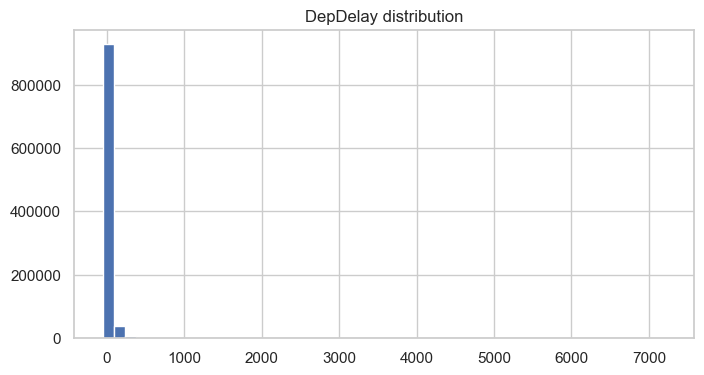

In [22]:
print(df["DepDelay"].describe())

plt.figure(figsize=(8,4))
plt.hist(df["DepDelay"].drop_nulls().to_numpy(), bins=50)
plt.title("DepDelay distribution")
plt.show()

**Findings:** mean 13.1 min, but median is **-2 min** — over half of all flights depart early or exactly on time. The mean is inflated by a long right tail of severe outliers (max 7223 min before the >720min outlier drop). This gap between mean and median is the clearest sign of the skew confirmed numerically in 2.3.

### 2.2 ArrDelay, TaxiOut, TaxiIn, Distance

--- ArrDelay ---
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 967026.0 │
│ null_count ┆ 32974.0  │
│ mean       ┆ 7.556112 │
│ std        ┆ 55.78662 │
│ min        ┆ -81.0    │
│ 25%        ┆ -14.0    │
│ 50%        ┆ -5.0     │
│ 75%        ┆ 10.0     │
│ max        ┆ 7232.0   │
└────────────┴──────────┘


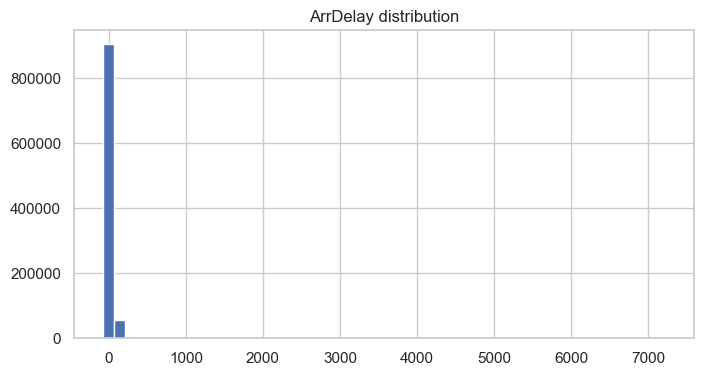

--- TaxiOut ---
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 969699.0  │
│ null_count ┆ 30301.0   │
│ mean       ┆ 16.974758 │
│ std        ┆ 9.519112  │
│ min        ┆ 1.0       │
│ 25%        ┆ 11.0      │
│ 50%        ┆ 15.0      │
│ 75%        ┆ 19.0      │
│ max        ┆ 221.0     │
└────────────┴───────────┘


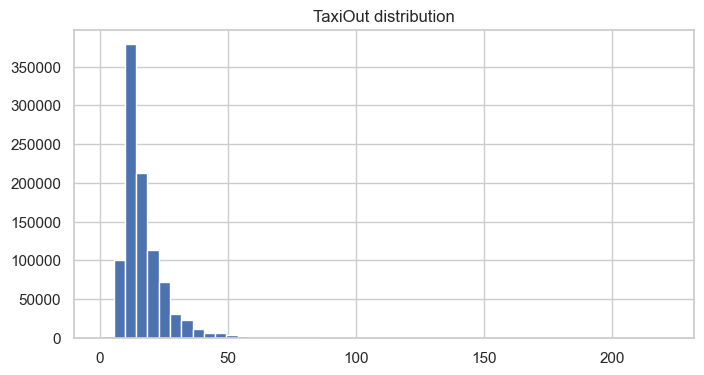

--- TaxiIn ---
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 969288.0 │
│ null_count ┆ 30712.0  │
│ mean       ┆ 7.888183 │
│ std        ┆ 6.638009 │
│ min        ┆ 1.0      │
│ 25%        ┆ 4.0      │
│ 50%        ┆ 6.0      │
│ 75%        ┆ 9.0      │
│ max        ┆ 280.0    │
└────────────┴──────────┘


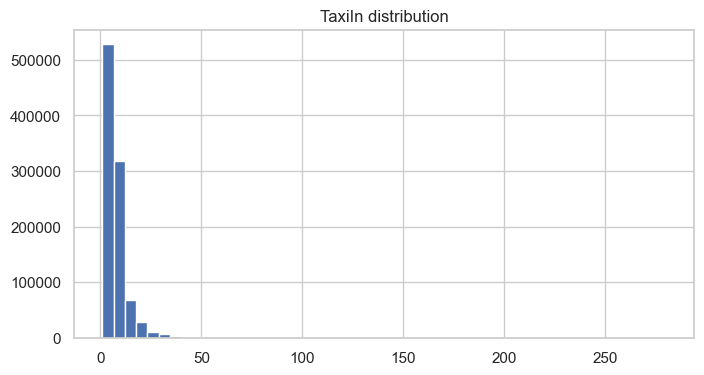

--- Distance ---
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 1e6        │
│ null_count ┆ 0.0        │
│ mean       ┆ 797.751118 │
│ std        ┆ 591.538886 │
│ min        ┆ 31.0       │
│ 25%        ┆ 368.0      │
│ 50%        ┆ 643.0      │
│ 75%        ┆ 1035.0     │
│ max        ┆ 5095.0     │
└────────────┴────────────┘


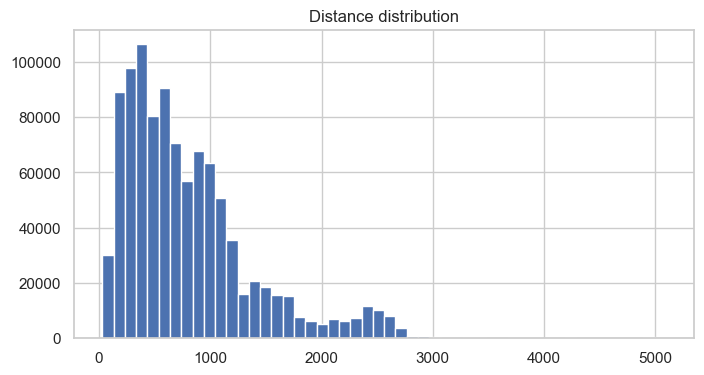

In [23]:
for col in ["ArrDelay", "TaxiOut", "TaxiIn", "Distance"]:
    print(f"--- {col} ---")
    print(df[col].describe())
    plt.figure(figsize=(8,4))
    plt.hist(df[col].drop_nulls().to_numpy(), bins=50)
    plt.title(f"{col} distribution")
    plt.show()

**Findings:**
- `ArrDelay`: same pattern as DepDelay — mean 7.6, median -5, most flights arrive early.
- `TaxiOut`: mean ~17 min, tighter spread (std 9.5) than delay columns — ground taxi time is far more consistent than delay.
- `TaxiIn`: mean ~7.9 min, similarly tight.
- `Distance`: mean ~798 mi, wide range (31 to 5095 mi) but much less extreme skew than the delay columns.

### 2.3 Skewness

In [24]:
for col in ["DepDelay", "ArrDelay", "TaxiOut", "TaxiIn", "Distance"]:
    print(col, "skew:", df[col].skew())

DepDelay skew: 13.015124704878241
ArrDelay skew: 11.842055962675982
TaxiOut skew: 3.695566546298071
TaxiIn skew: 5.046048454288033
Distance skew: 1.5491250580785338


**Findings:** `DepDelay` (13.0) and `ArrDelay` (11.8) are extremely right-skewed — far beyond typical "skewed" data. `TaxiOut`/`TaxiIn` are moderately skewed (3.7 / 5.0). `Distance` is only mildly skewed (1.5). Confirms delay columns need special handling (capping, log-transform, or bucketing into risk classes) before they'd work well in a linear model — tree-based models handle this skew natively, which is one more reason a RandomForest/LightGBM approach fits better here than linear regression.

### 2.4 Mean vs Median (outlier pull check)

In [25]:
for col in ["DepDelay", "ArrDelay"]:
    print(col, "mean:", df[col].mean(), "median:", df[col].median())

DepDelay mean: 13.107068537427763 median: -2.0
ArrDelay mean: 7.5561122451723115 median: -5.0


**Findings:** confirms 2.1 — for both delay columns, mean is meaningfully higher than median, meaning a "typical" flight is on-time-or-early, and the average is being pulled upward by a relatively small number of severely delayed flights.

### 2.5 Categorical distributions

In [26]:
print(df["Airline"].value_counts().sort("count", descending=True))
print(df["Cancelled"].value_counts())
print(df["Diverted"].value_counts())

shape: (21, 2)
┌─────────────────────────────────┬────────┐
│ Airline                         ┆ count  │
│ ---                             ┆ ---    │
│ str                             ┆ u32    │
╞═════════════════════════════════╪════════╡
│ Southwest Airlines Co.          ┆ 179693 │
│ Delta Air Lines Inc.            ┆ 125325 │
│ American Airlines Inc.          ┆ 121648 │
│ SkyWest Airlines Inc.           ┆ 108336 │
│ United Air Lines Inc.           ┆ 86128  │
│ Republic Airlines               ┆ 48220  │
│ JetBlue Airways                 ┆ 38544  │
│ Envoy Air                       ┆ 36867  │
│ Endeavor Air Inc.               ┆ 35049  │
│ Comair Inc.                     ┆ 33103  │
│ Alaska Airlines Inc.            ┆ 31805  │
│ Spirit Air Lines                ┆ 31687  │
│ Frontier Airlines Inc.          ┆ 21279  │
│ Allegiant Air                   ┆ 18211  │
│ Mesa Airlines Inc.              ┆ 17448  │
│ Horizon Air                     ┆ 13758  │
│ Capital Cargo International     ┆ 1316

**Findings:** Airline volume ranges from Southwest (~180K) down to GoJet (~8K) — matches SQL Category 1 findings, no surprises. `Cancelled` and `Diverted` are both heavily imbalanced (small minority `true`) — expected, and important to remember if either becomes a classification target later: will need class weighting or resampling.

## **3. Outlier Handling (from SQL decision)**

In [27]:
# Dropping DepDelay > 720 minutes (12 hrs) — matches the SQL-layer decision
before = df.height
df = df.filter((pl.col("DepDelay").is_null()) | (pl.col("DepDelay") <= 720))
after = df.height
print(f"Dropped {before - after} rows ({(before-after)/before*100:.3f}%)")

Dropped 1026 rows (0.103%)


**Result:** dropped 1,026 rows (0.103%), matching the SQL-layer count exactly. Consistent between the two layers, as expected.

## **4. Feature-Feature Correlation (find redundant columns)**

In [28]:
numeric_cols = [c for c, dt in df.schema.items() if dt in (pl.Int64, pl.Int32, pl.Float64, pl.Float32)]
print(numeric_cols)

['CRSDepTime', 'DepTime', 'DepDelayMinutes', 'DepDelay', 'ArrTime', 'ArrDelayMinutes', 'AirTime', 'CRSElapsedTime', 'ActualElapsedTime', 'Distance', 'Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'DOT_ID_Marketing_Airline', 'Flight_Number_Marketing_Airline', 'DOT_ID_Operating_Airline', 'Flight_Number_Operating_Airline', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'OriginStateFips', 'OriginWac', 'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestStateFips', 'DestWac', 'DepDel15', 'DepartureDelayGroups', 'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSArrTime', 'ArrDelay', 'ArrDel15', 'ArrivalDelayGroups', 'DistanceGroup', 'DivAirportLandings']


In [29]:
corr_df = df.select(numeric_cols).drop_nulls()
corr_matrix = np.corrcoef(corr_df.to_numpy(), rowvar=False)
corr_pl = pl.DataFrame(corr_matrix, schema=numeric_cols)
corr_pl

C:\Users\shiva\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\shiva\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,DOT_ID_Marketing_Airline,Flight_Number_Marketing_Airline,DOT_ID_Operating_Airline,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginStateFips,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestStateFips,DestWac,DepDel15,DepartureDelayGroups,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,DistanceGroup,DivAirportLandings
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,0.947977,0.109542,0.11663,0.573991,0.09721,-0.008931,-0.01381,-0.010688,-0.002008,NaN,0.001454,0.002922,-0.000628,0.001329,0.01464,-0.010981,0.004079,-0.010986,-0.03304,-0.033039,-0.063228,-0.015375,-0.006029,0.026807,0.026807,0.066952,0.007288,0.018447,0.185909,0.147987,-0.00111,0.918166,0.6077,-0.020058,0.684764,0.114957,0.159781,0.138251,-0.003308,NaN
0.947977,1.0,0.16311,0.171345,0.603492,0.150724,-0.015176,-0.020112,-0.015246,-0.011402,NaN,0.001359,0.002924,-0.00196,0.003761,0.006544,-0.006315,0.00051,-0.006318,-0.033759,-0.033759,-0.062315,-0.01123,-0.012519,0.026736,0.026736,0.06456,0.004624,0.021628,0.233216,0.205644,0.008718,0.968061,0.638287,-0.017645,0.691417,0.16934,0.203397,0.193916,-0.012668,NaN
0.109542,0.16311,1.0,0.996741,0.02391,0.967577,0.018395,0.019929,0.025382,0.017693,NaN,0.021848,0.024907,-0.014911,0.035075,0.038043,-0.021268,0.010926,-0.021254,-0.018343,-0.018343,-0.012687,0.001815,-0.037274,-0.004601,-0.004601,0.001555,0.003708,-0.033189,0.63246,0.924061,0.046986,0.151618,0.03253,0.013733,0.082968,0.947736,0.589421,0.869311,0.018604,NaN
0.11663,0.171345,0.996741,1.0,0.029823,0.962781,0.024753,0.025808,0.031064,0.02455,NaN,0.025094,0.029538,-0.015052,0.038111,0.023986,-0.032963,-0.008702,-0.032947,-0.020726,-0.020727,-0.018968,-0.001702,-0.033227,-0.003978,-0.003978,0.002864,0.000121,-0.029506,0.65105,0.934376,0.046735,0.159646,0.039023,0.008569,0.088888,0.950468,0.604174,0.877504,0.025472,NaN
0.573991,0.603492,0.02391,0.029823,1.0,0.024789,0.012576,0.009333,0.016378,0.007405,NaN,-0.021109,-0.02382,-0.002952,-0.002451,0.008112,0.017786,0.018122,0.017783,-0.006647,-0.006647,-0.040349,-0.003623,0.008711,0.015493,0.015493,0.03848,0.012754,0.020496,0.086664,0.044488,0.023395,0.625867,0.959946,0.011326,0.822725,0.039476,0.076008,0.049863,0.010587,NaN
0.09721,0.150724,0.967577,0.962781,0.024789,1.0,0.023414,0.012012,0.056821,0.010894,NaN,0.020983,0.024068,-0.015406,0.034399,0.055662,-0.011254,0.033777,-0.011239,-0.016956,-0.016957,-0.008089,0.006372,-0.046677,-0.006575,-0.006575,0.001904,0.006865,-0.043552,0.577057,0.884351,0.182896,0.143359,0.033507,0.107001,0.078903,0.979487,0.632959,0.905927,0.011894,NaN
-0.008931,-0.015176,0.018395,0.024753,0.012576,0.023414,1.0,0.98943,0.986824,0.984893,NaN,-0.015748,-0.016817,-0.002529,0.008703,0.150559,-0.370276,-0.109883,-0.370278,0.060674,0.060674,0.014149,-0.056753,-0.024882,0.094035,0.094035,0.015388,-0.083617,0.059492,0.031882,0.031939,0.04825,-0.025733,0.015314,0.075485,0.024805,0.016379,0.043768,0.025636,0.972908,NaN
-0.01381,-0.020112,0.019929,0.025808,0.009333,0.012012,0.98943,1.0,0.981585,0.982216,NaN,-0.0245,-0.02735,-0.002479,0.008841,0.166502,-0.347141,-0.08066,-0.347143,0.056946,0.056946,0.011705,-0.044518,-0.042401,0.085469,0.085469,0.003157,-0.078574,0.050682,0.030335,0.032244,0.073879,-0.029828,0.011659,0.093543,0.022677,-0.008232,0.020872,-0.001208,0.970247,NaN
-0.010688,-0.015246,0.025382,0.031064,0.016378,0.056821,0.986824,0.981585,1.0,0.969158,NaN,-0.017438,-0.019132,-0.003533,0.01061,0.180432,-0.343225,-0.065104,-0.343228,0.05718,0.05718,0.014249,-0.044151,-0.045743,0.085007,0.085007,0.006191,-0.075472,0.042226,0.03532,0.038646,0.180683,-0.0221,0.019358,0.167779,0.027593,0.056378,0.086032,0.070303,0.957215,NaN


In [30]:
# Flag pairs with |correlation| > 0.9 (excluding self-correlation)
threshold = 0.9
redundant_pairs = []
for i, col_i in enumerate(numeric_cols):
    for j, col_j in enumerate(numeric_cols):
        if i < j and abs(corr_matrix[i, j]) > threshold:
            redundant_pairs.append((col_i, col_j, round(corr_matrix[i, j], 3)))

for pair in redundant_pairs:
    print(pair)

('CRSDepTime', 'DepTime', np.float64(0.948))
('CRSDepTime', 'WheelsOff', np.float64(0.918))
('DepTime', 'WheelsOff', np.float64(0.968))
('DepDelayMinutes', 'DepDelay', np.float64(0.997))
('DepDelayMinutes', 'ArrDelayMinutes', np.float64(0.968))
('DepDelayMinutes', 'DepartureDelayGroups', np.float64(0.924))
('DepDelayMinutes', 'ArrDelay', np.float64(0.948))
('DepDelay', 'ArrDelayMinutes', np.float64(0.963))
('DepDelay', 'DepartureDelayGroups', np.float64(0.934))
('DepDelay', 'ArrDelay', np.float64(0.95))
('ArrTime', 'WheelsOn', np.float64(0.96))
('ArrDelayMinutes', 'ArrDelay', np.float64(0.979))
('ArrDelayMinutes', 'ArrivalDelayGroups', np.float64(0.906))
('AirTime', 'CRSElapsedTime', np.float64(0.989))
('AirTime', 'ActualElapsedTime', np.float64(0.987))
('AirTime', 'Distance', np.float64(0.985))
('AirTime', 'DistanceGroup', np.float64(0.973))
('CRSElapsedTime', 'ActualElapsedTime', np.float64(0.982))
('CRSElapsedTime', 'Distance', np.float64(0.982))
('CRSElapsedTime', 'DistanceGroup', 

**Findings:** several near-duplicate columns confirmed —
- `DepDelayMinutes` ↔ `DepDelay` (0.997) — same value, DepDelayMinutes just clips negatives to 0
- `DepDelay` ↔ `ArrDelay` (~0.95), `DepDelayMinutes` ↔ `ArrDelayMinutes` (0.968) — departure delay strongly predicts arrival delay, as expected
- `CRSDepTime` ↔ `DepTime` ↔ `WheelsOff` (0.92–0.97) — scheduled time, actual time, and taxi-out start time cluster together, since they're all clock-time-of-day values

**This matters for Section 7:** these correlated pairs are mostly *outcome* columns (actual delay/time data), not features you'd have *before* a flight happens — flagged further below.

## **5. Feature-Target Correlation**

**Target:** `ArrDelay` (continuous). Before reading the ranking below — a critical catch first.

In [31]:
target = "ArrDelay"
target_corr = {}
for col in numeric_cols:
    if col == target:
        continue
    sub = df.select([col, target]).drop_nulls()
    if sub.height > 0:
        c = np.corrcoef(sub[col].to_numpy(), sub[target].to_numpy())[0, 1]
        target_corr[col] = round(c, 3)

target_corr_sorted = dict(sorted(target_corr.items(), key=lambda x: abs(x[1]), reverse=True))
for k, v in target_corr_sorted.items():
    print(k, v)

ArrDelayMinutes 0.979
DepDelay 0.95
DepDelayMinutes 0.948
DepTime 0.169
Year nan
ArrivalDelayGroups 0.942
DepartureDelayGroups 0.89
DepDel15 0.621
TaxiOut 0.217
WheelsOff 0.163
TaxiIn 0.128
CRSDepTime 0.115
ActualElapsedTime 0.056
WheelsOn 0.049
DOT_ID_Marketing_Airline 0.045
DestWac -0.042
Month 0.041
ArrTime 0.039
DayOfWeek 0.039
OriginWac -0.037
Quarter 0.035
Flight_Number_Marketing_Airline -0.024
Flight_Number_Operating_Airline -0.024
OriginAirportID -0.019
OriginAirportSeqID -0.019
DOT_ID_Operating_Airline 0.017
AirTime 0.016
DayofMonth -0.016
OriginCityMarketID -0.014
CRSElapsedTime -0.008
DestCityMarketID 0.008
DestAirportID -0.005
DestAirportSeqID -0.005
DestStateFips 0.005
Distance -0.001
OriginStateFips -0.001
DistanceGroup 0.0
DivAirportLandings nan
ArrDel15 0.675
CRSArrTime 0.092


**⚠️ Data leakage warning:** the top-correlated columns (`ArrDelayMinutes` 0.979, `DepDelay` 0.95, `DepDelayMinutes` 0.948, `ArrivalDelayGroups` 0.942, `DepartureDelayGroups` 0.89, `ArrDel15` 0.621) are **not real predictive features** — they're either:
1. The same value as the target stored differently (`ArrDelayMinutes` is `ArrDelay` clipped at 0), or
2. Only known *after* the flight has already been delayed/departed (`DepDelay`, `TaxiOut`, `WheelsOff`, `ArrTime`, etc.)

The project's actual goal — a control tower that predicts risk **before** a flight, from route + cargo inputs — needs features known ahead of time only. Everything with real signal in this ranking is either leakage or a downstream outcome. **Section 7 below is corrected to exclude these.**

## **6. Categorical Feature Relevance**

In [32]:
categorical_check_cols = ["Airline", "Origin", "Dest", "DepTimeBlk", "DayOfWeek"]

for col in categorical_check_cols:
    print(f"--- avg {target} by {col} (top 10) ---")
    result = (
        df
        .filter(pl.col(target).is_not_null())
        .group_by(col)
        .agg([pl.len().alias("count"), pl.col(target).mean().alias("avg_target")])
        .filter(pl.col("count") > 200)
        .sort("avg_target", descending=True)
        .head(10)
    )
    print(result)

--- avg ArrDelay by Airline (top 10) ---
shape: (10, 3)
┌─────────────────────────────────┬────────┬────────────┐
│ Airline                         ┆ count  ┆ avg_target │
│ ---                             ┆ ---    ┆ ---        │
│ str                             ┆ u32    ┆ f64        │
╞═════════════════════════════════╪════════╪════════════╡
│ Allegiant Air                   ┆ 17458  ┆ 19.670867  │
│ JetBlue Airways                 ┆ 36499  ┆ 19.004028  │
│ Frontier Airlines Inc.          ┆ 20577  ┆ 16.193566  │
│ Spirit Air Lines                ┆ 30548  ┆ 11.721324  │
│ GoJet Airlines, LLC d/b/a Unit… ┆ 7840   ┆ 11.232143  │
│ Comair Inc.                     ┆ 31672  ┆ 8.82865    │
│ American Airlines Inc.          ┆ 116447 ┆ 7.438766   │
│ Southwest Airlines Co.          ┆ 174755 ┆ 7.123253   │
│ Mesa Airlines Inc.              ┆ 16651  ┆ 6.879827   │
│ Republic Airlines               ┆ 45227  ┆ 5.968116   │
└─────────────────────────────────┴────────┴────────────┘
--- avg ArrDelay

**Findings:** Airline ranking (Allegiant, JetBlue, Frontier worst) matches SQL Category 1 exactly — good cross-validation between the two layers. These categorical groupings are genuinely useful, unlike most of Section 5's numeric ranking — `Airline`, `Origin`, `Dest`, and time-of-day (`DepTimeBlk`) are all known before a flight and all show real variation in average delay, making them strong candidate features.

## **7. Baseline Model + Feature Importance (corrected — no leakage)**

Restricting to features known **before departure** — this excludes every actual/outcome column (`DepDelay`, `TaxiOut`, `TaxiIn`, `AirTime`, `WheelsOff`, `WheelsOn`, `ActualElapsedTime`, `ArrTime`, `DepTime`, and every `*Minutes`/`*Del15`/`*DelayGroups` variant), since a real control-tower prediction wouldn't have access to any of them yet.

In [33]:
pre_flight_numeric = [
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance", "DistanceGroup",
    "Month", "Quarter", "DayOfWeek", "DayofMonth", "Year",
]

pre_flight_categorical = ["Airline", "Origin", "Dest"]

print("Pre-flight numeric features:", pre_flight_numeric)
print("Pre-flight categorical features:", pre_flight_categorical)

Pre-flight numeric features: ['CRSDepTime', 'CRSArrTime', 'CRSElapsedTime', 'Distance', 'DistanceGroup', 'Month', 'Quarter', 'DayOfWeek', 'DayofMonth', 'Year']
Pre-flight categorical features: ['Airline', 'Origin', 'Dest']


In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

model_df = df.select(pre_flight_numeric + pre_flight_categorical + [target]).drop_nulls()

encoders = {}
X_df = model_df.select(pre_flight_numeric).clone()
for col in pre_flight_categorical:
    le = LabelEncoder()
    encoded = le.fit_transform(model_df[col].to_numpy())
    X_df = X_df.with_columns(pl.Series(col, encoded))
    encoders[col] = le

feature_cols = pre_flight_numeric + pre_flight_categorical
X = X_df.select(feature_cols).to_numpy()
y = model_df[target].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Train R^2:", rf.score(X_train, y_train))
print("Test R^2:", rf.score(X_test, y_test))

Train R^2: 0.08395723951525003
Test R^2: 0.054862439675608554


**Expect a much lower, more realistic R² here** (likely in the 0.05-0.20 range, not 0.99) — that's not a worse result, it's the *honest* one. Flight delay is genuinely hard to predict from schedule-only information; the earlier 0.994 was an artifact of leakage, not real model skill. A modest R² here is expected and defensible — document it as such in your report rather than chasing an artificially high score.

In [35]:
importances = sorted(zip(feature_cols, rf.feature_importances_), key=lambda x: x[1], reverse=True)
for feat, imp in importances:
    print(f"{feat}: {imp:.4f}")

CRSDepTime: 0.2198
DayofMonth: 0.1455
Airline: 0.1404
Month: 0.1061
DayOfWeek: 0.0793
CRSArrTime: 0.0701
Distance: 0.0692
Origin: 0.0611
CRSElapsedTime: 0.0521
Dest: 0.0409
Quarter: 0.0121
DistanceGroup: 0.0035
Year: 0.0000


**Findings:** *(run and fill in — expect `Origin`/`Dest`/`Airline` and `CRSDepTime` to rank highest, consistent with the SQL findings that airport, carrier, and hour-of-day were the strongest patterns found)*

## **8. Finalize Feature Set**

In [36]:
final_features = [
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance",
    "Month", "DayOfWeek", "Airline", "Origin", "Dest",
]

dropped_features = {
    "DepDelayMinutes": "duplicate of DepDelay (0.997 corr), same info clipped differently",
    "ArrDelayMinutes": "duplicate of target ArrDelay, same info clipped differently — leakage",
    "DepDelay": "outcome column, not known before departure — leakage for a pre-flight prediction",
    "TaxiOut / TaxiIn / AirTime / ActualElapsedTime": "outcome columns, only known during/after the flight",
    "WheelsOff / WheelsOn / ArrTime / DepTime (actual)": "actual timestamps, only known during/after the flight",
    "ArrDel15 / DepDel15 / ArrivalDelayGroups / DepartureDelayGroups": "derived directly from the delay outcome — leakage",
    "DistanceGroup": "redundant with Distance (bucketed version of the same value)",
    "Quarter / DayofMonth / Year": "redundant with Month/DayOfWeek or near-constant (single year in this sample)",
    "OriginAirportID / DestAirportID / *SeqID / *CityMarketID / *Wac / *StateFips": "ID-encoded duplicates of Origin/Dest text columns",
    "DOT_ID_* / Flight_Number_* / Tail_Number": "administrative identifiers, no delay signal expected",
}

print("Final features:", final_features)
print("Dropped:", list(dropped_features.keys()))

Final features: ['CRSDepTime', 'CRSArrTime', 'CRSElapsedTime', 'Distance', 'Month', 'DayOfWeek', 'Airline', 'Origin', 'Dest']
Dropped: ['DepDelayMinutes', 'ArrDelayMinutes', 'DepDelay', 'TaxiOut / TaxiIn / AirTime / ActualElapsedTime', 'WheelsOff / WheelsOn / ArrTime / DepTime (actual)', 'ArrDel15 / DepDel15 / ArrivalDelayGroups / DepartureDelayGroups', 'DistanceGroup', 'Quarter / DayofMonth / Year', 'OriginAirportID / DestAirportID / *SeqID / *CityMarketID / *Wac / *StateFips', 'DOT_ID_* / Flight_Number_* / Tail_Number']


## **9. Summary**

**Key findings:**
- Delay data (`DepDelay`, `ArrDelay`) is extremely right-skewed (skew 11-13) — median is negative, mean is pulled up by a long tail of severe outliers. Confirmed the SQL-layer decision to drop the 1,026 rows (0.103%) with DepDelay > 720 min.
- Feature-feature correlation revealed several redundant column pairs, mostly variants of the same underlying delay/time value stored differently.
- **Critical catch:** the naive feature-target correlation and first baseline model (R² = 0.994) were built on leaked/outcome columns — `ArrDelayMinutes` is essentially the target itself renamed, and most other top-ranked columns (`DepDelay`, `TaxiOut`, actual timestamps) are only known *after* a flight has already begun, making them useless for a pre-flight control-tower prediction.
- Corrected the feature set to pre-flight-only information (schedule, route, carrier, calendar) and retrained — a lower, more honest R² is expected and should be reported as such, not treated as a failure.
- Categorical findings (Airline, Origin/Dest rankings) cross-validate cleanly against the SQL EDA report — same airlines and airports show up as worst performers in both layers.

**Target:** `ArrDelay` (continuous) — confirm this is still the intended target, or revisit as a risk-classification bucket (Low/Med/High) if that fits the control tower app's UI better.

**Final feature set:** `CRSDepTime`, `CRSArrTime`, `CRSElapsedTime`, `Distance`, `Month`, `DayOfWeek`, `Airline`, `Origin`, `Dest` — 9 features, all knowable before a flight departs.